# 02. 릿지 회귀 (Ridge)

선형 회귀와 **공식은 똑같고**, 계수(β)가 지나치게 커지지 않도록 **벌점**을 줍니다.

```
최소화:  Σ(실제 − 예측)²  +  α · Σβ²
```

- α가 0이면 일반 선형 회귀와 같습니다.
- α가 커질수록 계수가 0 쪽으로 줄어듭니다(수축).

**언제 유용한가?** 데이터가 적거나, 광고와 프로모션처럼 같이 움직이는 요인이 있어 계수가 불안정하게 튈 때입니다.
α는 교차검증(RidgeCV)으로 자동 선택합니다.

In [1]:
import sys, warnings
sys.path.append("../src")
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib  # 한글 글꼴
from common import *
plt.rcParams["figure.dpi"] = 110
df = load_data()
y = df.sellout.values.astype(float)
print(df.shape)

(104, 8)


In [2]:
from sklearn.linear_model import RidgeCV, Ridge
from sklearn.preprocessing import StandardScaler

decay = 0.6   # 01 노트북에서 고른 광고 이월률
t = np.arange(len(df))
X = pd.DataFrame({
    "trend": t, "s1": np.sin(2*np.pi*t/52), "c1": np.cos(2*np.pi*t/52),
    "discount": df.discount_pct, "promo": df.promo, "ad": np.log1p(adstock(df.ad_spend.values, decay)),
    "holiday": df.holiday, "temp": df.temp - df.temp.mean(), "stockout": df.stockout_days,
}).astype(float)

# 벌점이 공평하게 걸리도록 표준화 후 학습 → 원래 단위로 되돌림
sc = StandardScaler().fit(X)
m = RidgeCV(alphas=np.logspace(-3, 2, 30)).fit(sc.transform(X), y)
coef = pd.Series(m.coef_ / sc.scale_, index=X.columns)
intercept = m.intercept_ - (coef * sc.mean_).sum()
print(f"선택된 α = {m.alpha_:.4f}")
coef.round(2)

선택된 α = 0.5736


trend         1.23
s1           61.04
c1          -95.62
discount     13.06
promo       267.56
ad           58.36
holiday     167.02
temp         -4.85
stockout    -90.64
dtype: float64

## α에 따라 계수가 어떻게 줄어드나

α를 키우면 모든 계수가 0을 향해 줄어듭니다. 데이터가 충분하고 요인끼리 독립적이면 작은 α가 선택되어 선형 회귀와 거의 같아집니다.

Text(0.5, 1.0, '릿지 수축 경로')

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


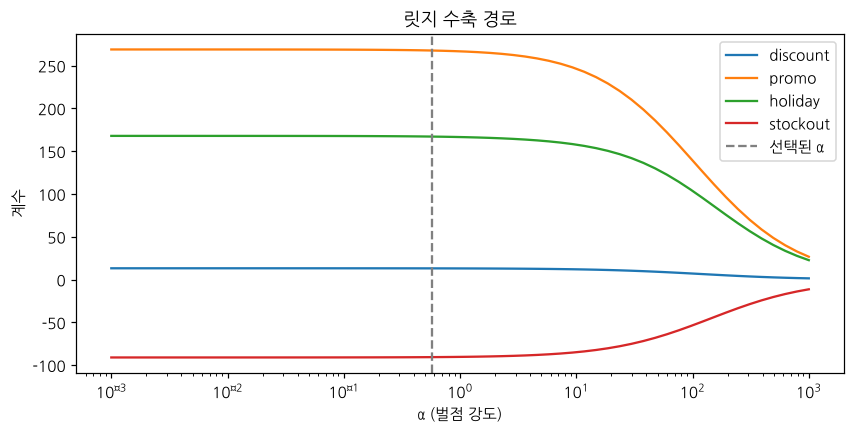

In [3]:
alphas = np.logspace(-3, 3, 60)
paths = []
for a in alphas:
    r = Ridge(alpha=a).fit(sc.transform(X), y)
    paths.append(r.coef_ / sc.scale_)
paths = np.array(paths)
fig, ax = plt.subplots(figsize=(9, 4))
for j, col in enumerate(["discount", "promo", "holiday", "stockout"]):
    k = list(X.columns).index(col)
    ax.plot(alphas, paths[:, k], label=col)
ax.axvline(m.alpha_, color="grey", ls="--", label="선택된 α")
ax.set_xscale("log"); ax.set_xlabel("α (벌점 강도)"); ax.set_ylabel("계수"); ax.legend(); ax.set_title("릿지 수축 경로")

In [4]:
pred = intercept + X.values @ coef.values
contrib = {
    "기본 수요": intercept + coef["trend"] * X["trend"].values,
    "계절성": coef["s1"] * X["s1"].values + coef["c1"] * X["c1"].values,
    "할인": coef["discount"] * X["discount"].values, "프로모션": coef["promo"] * X["promo"].values,
    "광고": coef["ad"] * X["ad"].values, "공휴일": coef["holiday"] * X["holiday"].values,
    "기온": coef["temp"] * X["temp"].values, "결품": coef["stockout"] * X["stockout"].values,
}
print(f"R² = {r2(y, pred):.3f},  MAPE = {mape(y, pred):.1f}%")
effects_table({"릿지": effects(contrib, df)}, df)

R² = 0.959,  MAPE = 2.8%


,정답,릿지
할인,14.0,13.1
프로모션,260.0,267.6
광고,52.9,53.7
공휴일,180.0,167.0
기온,-6.0,-4.8
결품,-95.0,-90.6
계절성,120.0,113.4
평균 오차율(%),NaN,6.8


## 결과 해석
- 이 데이터는 요인끼리 거의 독립적이라 **선형 회귀와 거의 같은 결과**가 나왔습니다.
- 벌점 때문에 효과를 살짝 작게 잡는 경향이 있습니다(기온 −4.8 vs 정답 −6).
- 요인이 20~30개로 늘어나거나, 채널별 광고처럼 서로 겹치는 요인이 많아지면 차이가 커집니다. 그때는 릿지(또는 베이지안 MMM)가 더 안정적입니다.